# Lab 07 — Convolutional Neural Networks (CNN): Chest X-Ray Classification

**DSA 8401 — Applied Machine Learning**

### Learning goals
By the end of this lab you should be able to:
1. Explain why CNNs (not plain MLPs) are used for image data.
2. Load an image dataset straight from folders.
3. Build a simple CNN with Conv2D and MaxPooling layers.
4. Train the CNN and watch for overfitting.
5. Evaluate the CNN on a held-out test set.

**Core question:** Can a small CNN tell NORMAL chest X-rays apart from PNEUMONIA/COVID-19 X-rays?

**Dataset:** `Data/xray_dataset_covid19/` — already split into `train/` and `test/` folders,
each with a `NORMAL` folder and a `PNEUMONIA` folder.

In [1]:
# Step 1: Import the libraries we need
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.metrics import confusion_matrix, classification_report

# Make results repeatable
SEED = 42
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


## 1. Load the images from folders

Keras can build a dataset directly from a folder structure like:

```
train/NORMAL/...jpeg
train/PNEUMONIA/...jpeg
test/NORMAL/...jpeg
test/PNEUMONIA/...jpeg
```

We split `train/` further into a training set and a small validation set.

In [2]:
# Step 2: Point to the data folders
train_dir = r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\xray_dataset_covid19\train"
test_dir  = r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\xray_dataset_covid19\test"

IMG_SIZE = (150, 150)   # resize every image to 150x150 pixels
BATCH_SIZE = 16         # small batches since we only have a few hundred images

In [3]:
# Step 3: Build the training dataset (80% of train/)
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    color_mode="grayscale",   # X-rays are black and white, so 1 colour channel is enough
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Step 4: Build the validation dataset (the other 20% of train/)
val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Step 5: Build the test dataset (completely separate images, used only at the end)
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,   # keep the order so labels line up with predictions later
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 148 files belonging to 2 classes.


Using 119 files for training.


Found 148 files belonging to 2 classes.


Using 29 files for validation.


Found 40 files belonging to 2 classes.


Classes: ['NORMAL', 'PNEUMONIA']


## 2. Look at the data

Always look at a few images before building a model. This confirms the images loaded
correctly and that the labels make sense.

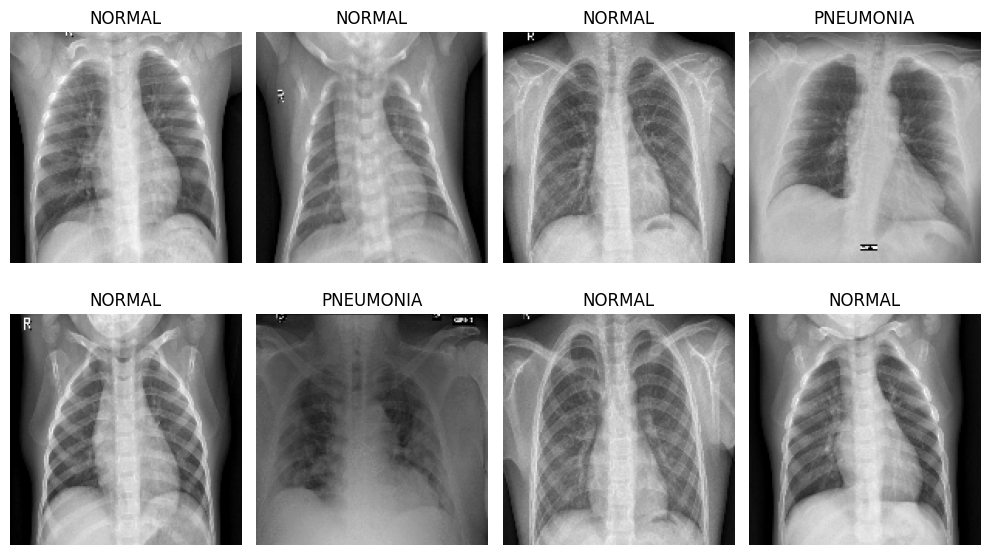

In [4]:
# Step 6: Plot a few training images with their labels
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):     # grab one batch
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Speed up data loading

`cache()` keeps the images in memory after the first epoch and `prefetch()` prepares the
next batch while the current one is training. This does not change the model, only the speed.

In [5]:
# Step 7: Cache and prefetch the datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

## 4. Build a simple CNN

Architecture:

**Rescale pixels -> [Conv2D -> MaxPool] x 3 -> Flatten -> Dense -> Dropout -> Sigmoid**

- **Rescaling:** pixel values go from 0-255 down to 0-1, which trains better.
- **Conv2D:** learns small visual patterns (edges, shapes) using filters.
- **MaxPooling2D:** shrinks the image, keeping only the strongest signals.
- **Flatten:** turns the final feature map into a single vector.
- **Dropout:** randomly switches off neurons during training to reduce overfitting.
- **Sigmoid:** outputs a probability of PNEUMONIA vs NORMAL.

In [6]:
# Step 8: Define the CNN, layer by layer
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),   # 150x150 grayscale images

    layers.Rescaling(1. / 255),   # scale pixels from [0, 255] to [0, 1]

    layers.Conv2D(16, 3, activation="relu"),   # learn 16 small filters
    layers.MaxPooling2D(),                     # shrink the image by half

    layers.Conv2D(32, 3, activation="relu"),   # learn 32 filters on smaller features
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),   # learn 64 filters on even smaller features
    layers.MaxPooling2D(),

    layers.Flatten(),                  # turn the 2D feature maps into a 1D vector
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),               # switch off 30% of neurons at random while training
    layers.Dense(1, activation="sigmoid"),   # 1 = PNEUMONIA, 0 = NORMAL
])

In [7]:
# Step 9: Compile the model
model.compile(
    optimizer="adam",              # gradient descent algorithm
    loss="binary_crossentropy",    # loss for two-class problems
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,169 (4.60 MB)

 Trainable params: 1,207,169 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model

We watch **validation accuracy** and stop early if it stops improving, so we do not
overfit on this small dataset.

In [8]:
# Step 10: Train with early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
)

Epoch 1/20



1/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3125 - loss: 0.7032


3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3715 - loss: 0.7650


5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4035 - loss: 0.7619


7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4173 - loss: 0.7544

...


1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0032


3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9931 - loss: 0.0241


5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9877 - loss: 0.0351


7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9829 - loss: 0.0426


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9811 - loss: 0.0455 - val_accuracy: 0.9655 - val_loss: 0.0800


## 6. Plot the training curves

If training accuracy keeps rising while validation accuracy flattens or drops,
the model is overfitting.

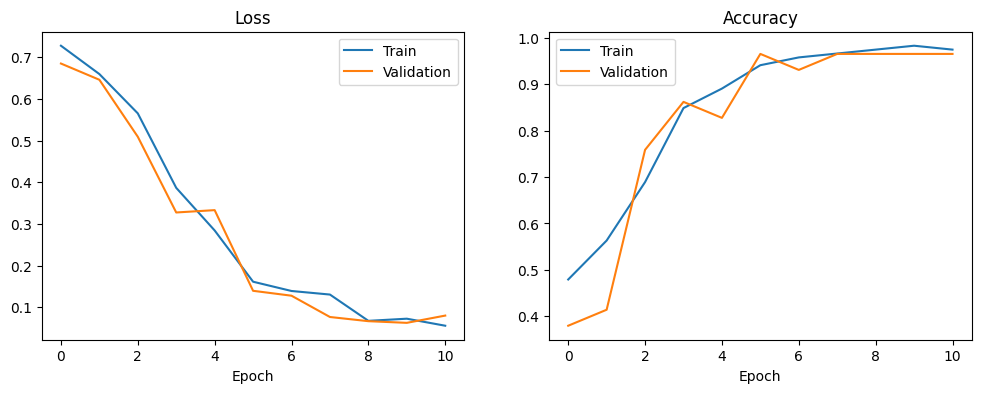

In [9]:
# Step 11: Plot loss and accuracy for train vs validation
h = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(h["loss"], label="Train")
plt.plot(h["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h["accuracy"], label="Train")
plt.plot(h["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

## 7. Evaluate on the test set

The test images were never used for training or validation, so this is our best
estimate of real-world performance.

In [10]:
# Step 12: Evaluate overall test accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2%}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0307


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.0385


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0487


Test accuracy: 100.00%


In [11]:
# Step 13: Get predictions and true labels for the test set
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob > 0.5).astype(int)   # turn probability into a 0/1 class

print(classification_report(y_true, y_pred, target_names=class_names))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



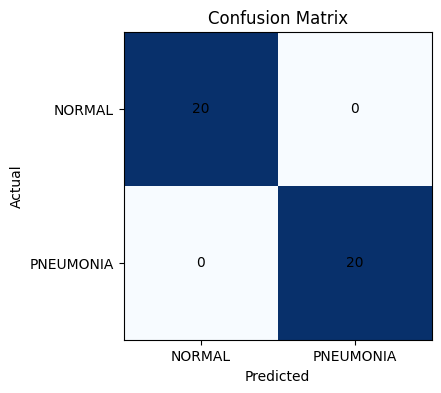

In [12]:
# Step 14: Confusion matrix -- where does the model get confused?
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 8. Look at a few predictions

A quick visual check: does the model's prediction match the true label?

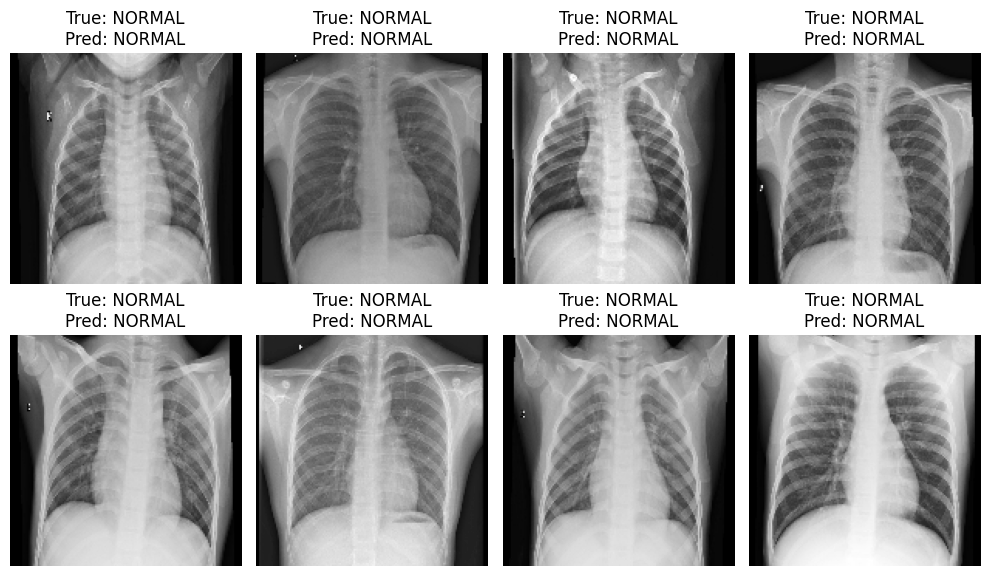

In [13]:
# Step 15: Show 8 test images with predicted vs true label
plt.figure(figsize=(10, 6))

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0).ravel()
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        true_label = class_names[int(labels[i])]
        pred_label = class_names[int(preds[i] > 0.5)]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Summary

### What should you remember?

1. **Conv2D + MaxPooling** layers let a network learn visual patterns instead of
   treating every pixel as an independent feature (unlike an MLP).
2. **Rescaling** pixel values to [0, 1] helps training.
3. **Dropout** and **early stopping** help control overfitting, which matters even
   more on small image datasets like this one (only ~150 training images).
4. Always check performance on a **separate test set** that the model never saw
   during training or validation.
5. A **confusion matrix** shows not just accuracy but *which* class is being
   confused with the other -- important in a medical context like this one